In [1]:
from votekit.cvr_loaders import load_scottish, load_numpy

portland_D1 = load_scottish("/home/nardo/research/data/election_data/votekit/portland/portland_d1_2024.csv")[0]

portland_D1

RankProfile
Maximum ranking length: 6
Candidates: ('Steph Routh', 'Thomas Shervey', 'Jamie Dunphy', 'Joe Furi', 'Doug Clove', 'Candace Avalos', 'Michael (Mike) Sands', 'Cayle Tern', 'Peggy Sue Owens', 'Terrence Hayes', 'David Linn', 'Noah Ernst', 'Timur Ender', 'Deian Salazar', 'Loretta Smith', 'Joe Allen')
Candidates who received votes: ('Joe Furi', 'Steph Routh', 'Joe Allen', 'Deian Salazar', 'Noah Ernst', 'Michael (Mike) Sands', 'David Linn', 'Candace Avalos', 'Jamie Dunphy', 'Thomas Shervey', 'Loretta Smith', 'Timur Ender', 'Peggy Sue Owens', 'Cayle Tern', 'Terrence Hayes', 'Doug Clove')
Total number of Ballot objects: 18723
Total weight of Ballot objects: 42678.0

In [2]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor

constructor = WIGMGraphConstructor(profile = portland_D1, m =3, LAM =670, memory_lite = True)
constructor.build()
constructor.add_natural_edges()
constructor.coherence_check()

Coherence check passed.
  terminal vertices: 9
  winner set: ['Jamie Dunphy', 'Candace Avalos', 'Loretta Smith']


True

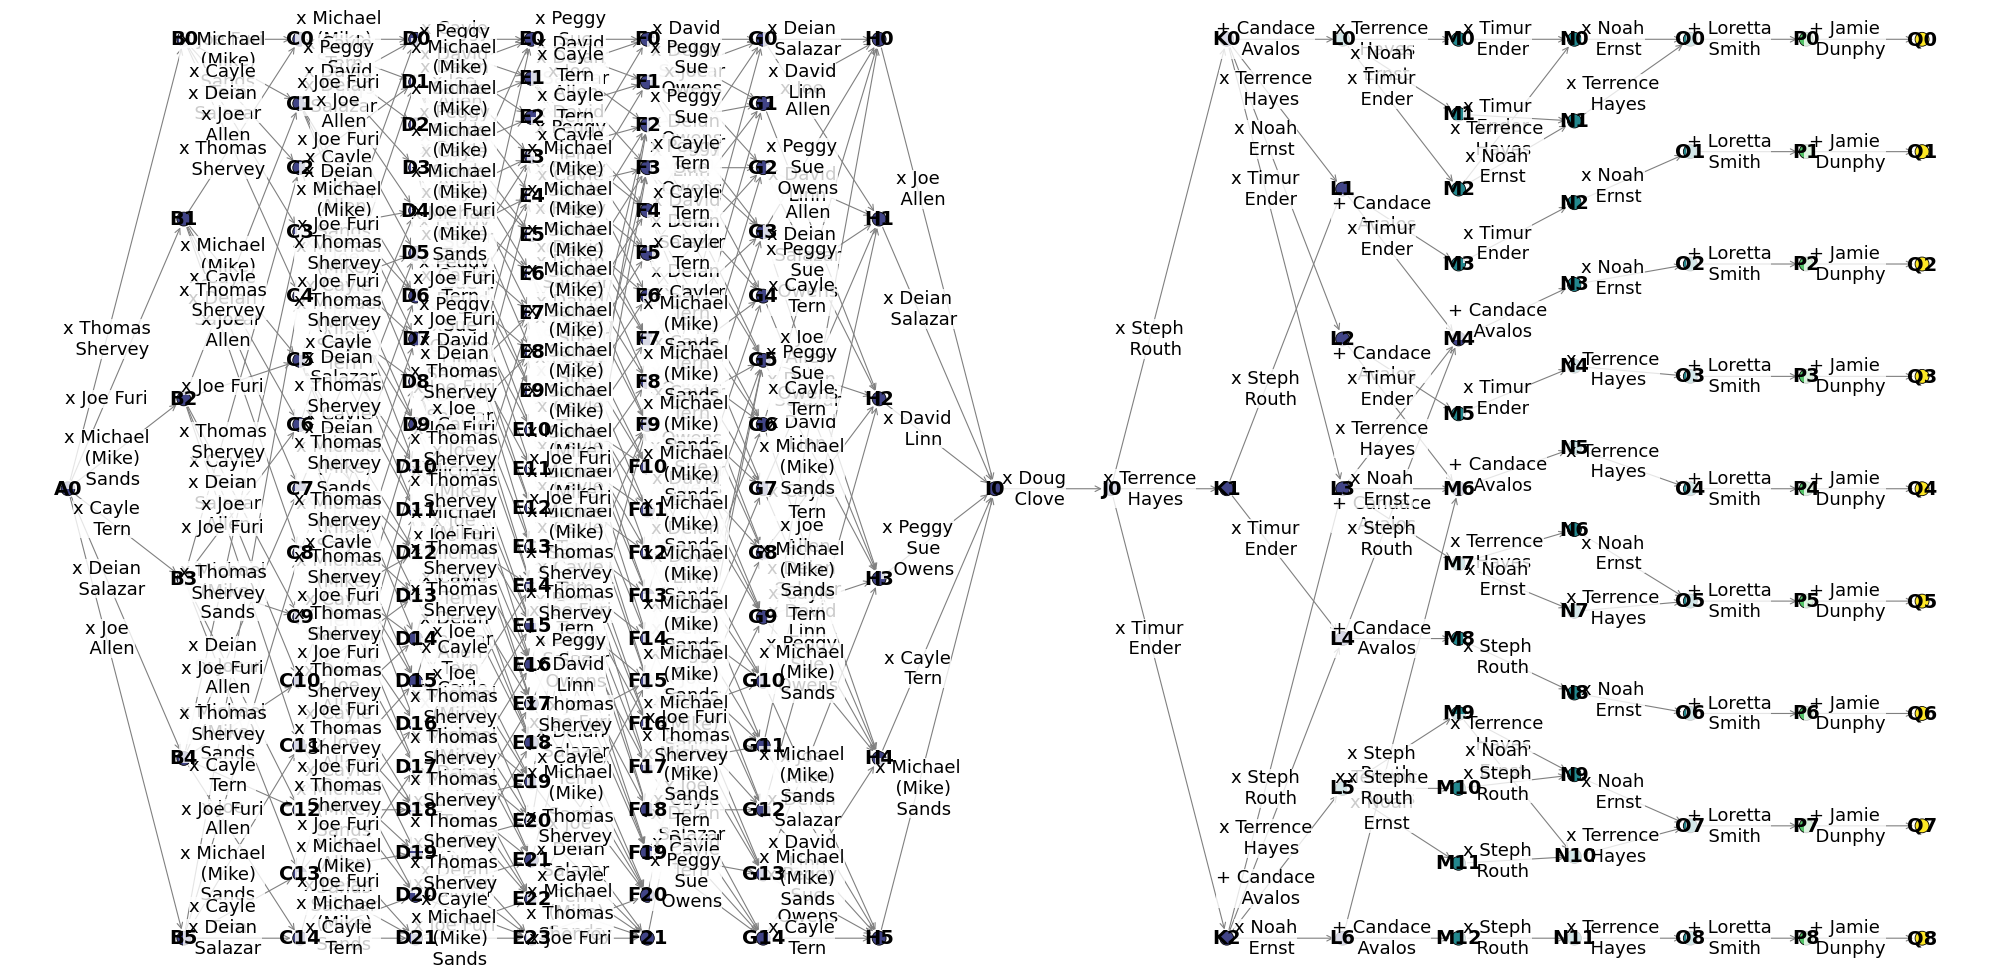

In [3]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 10),
    node_size=100,
    font_size=14,
    #label_edges=None,
    label_vertices=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"
)

In [12]:
from src.test_processes.driver import GlobalAuditDriver

driver = GlobalAuditDriver(
    constructor,
    fractional_sample_size = 0.5,
    noise_level=0.01,
    compiler_type = "noise"
)

#for compiler in driver.compilers:
#    compiler.lambda_value = 1.5

Removed 153 duplicate compilers.


In [11]:
driver.run(ballot_matrix=constructor.ballot_matrix)

Audit diagnostic after 30 samples: 2420 compilers remain below threshold (0/2420 certified).
  N7-W2: M=1.09257, escape=ELECT 2:Jamie Dunphy, margin=335.04540225157507, kind=CobraNoiseFilterCompiler
  N1-E2: M=1.09279, escape=ELIMINATE 2:Jamie Dunphy, margin=335.7952544967238, kind=CobraNoiseFilterCompiler
  H2-E4: M=1.09328, escape=ELIMINATE 4:Doug Clove, margin=337.5, kind=CobraNoiseFilterCompiler
  N8-W2: M=1.09438, escape=ELECT 2:Jamie Dunphy, margin=341.29593292903064, kind=CobraNoiseFilterCompiler
  G5-E4: M=1.09517, escape=ELIMINATE 4:Doug Clove, margin=344.0, kind=CobraNoiseFilterCompiler
Audit diagnostic after 60 samples: 2420 compilers remain below threshold (0/2420 certified).
  N7-W2: M=1.19372, escape=ELECT 2:Jamie Dunphy, margin=335.04540225157507, kind=CobraNoiseFilterCompiler
  N1-E2: M=1.19419, escape=ELIMINATE 2:Jamie Dunphy, margin=335.7952544967238, kind=CobraNoiseFilterCompiler
  H2-E4: M=1.19527, escape=ELIMINATE 4:Doug Clove, margin=337.5, kind=CobraNoiseFilterCo

False